In [5]:
import sqlite3  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from scipy.stats import gaussian_kde
import shapely  
from shapely import wkt  
from shapely.geometry import Polygon  
import os  
import shapely.ops
from matplotlib.pyplot import scatter

In [6]:
def process_polygon(wkt_string):
    try:
        polygon = wkt.loads(wkt_string)
        
        if polygon.geom_type == 'MultiPolygon':
            polygon = max(polygon.geoms, key=lambda p: p.area)
        
        if not polygon.is_simple:
            polygon = polygon.buffer(0)
        
        return polygon
    
    except Exception as e:
        print(f"处理多边形时出错: {e}")
        return None

In [11]:
import os
import glob

# 检查目录是否存在
layout = 'Exit'
base_dir = f"./Big_Average/{layout}/"
print(f"检查目录: {base_dir}")
print(f"目录是否存在: {os.path.exists(base_dir)}")

if os.path.exists(base_dir):
    # 列出目录中的所有文件
    print("\n目录中的文件:")
    files = os.listdir(base_dir)
    for file in sorted(files):
        print(f"  {file}")
    
    # 查找所有 .sqlite 文件
    sqlite_files = glob.glob(os.path.join(base_dir, "*.sqlite"))
    print(f"\n找到的 sqlite 文件数量: {len(sqlite_files)}")
    for file in sorted(sqlite_files):
        print(f"  {os.path.basename(file)}")
else:
    print("目录不存在!")
    
    # 检查上一级目录
    print("\n检查 Big_Average 目录:")
    big_avg_dir = "./Big_Average/"
    if os.path.exists(big_avg_dir):
        subdirs = [d for d in os.listdir(big_avg_dir) if os.path.isdir(os.path.join(big_avg_dir, d))]
        print(f"Big_Average 中的子目录: {subdirs}")
    else:
        print("Big_Average 目录也不存在!")


检查目录: ./Big_Average/Exit/
目录是否存在: False
目录不存在!

检查 Big_Average 目录:
Big_Average 目录也不存在!


读取 ./Big_Average/Exit/Width_1.0_0.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.0_1.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.0_2.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.0_3.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.0_4.sqlite 失败: unable to open database file
宽度 1.0 的数据处理失败
读取 ./Big_Average/Exit/Width_1.2_0.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.2_1.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.2_2.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.2_3.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.2_4.sqlite 失败: unable to open database file
宽度 1.2 的数据处理失败
读取 ./Big_Average/Exit/Width_1.4_0.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.4_1.sqlite 失败: unable to open database file
读取 ./Big_Average/Exit/Width_1.4_2.sqlite 失败: unable to open database file
读取 ./Big

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/trajectory_overlay_layout_Exit.png'

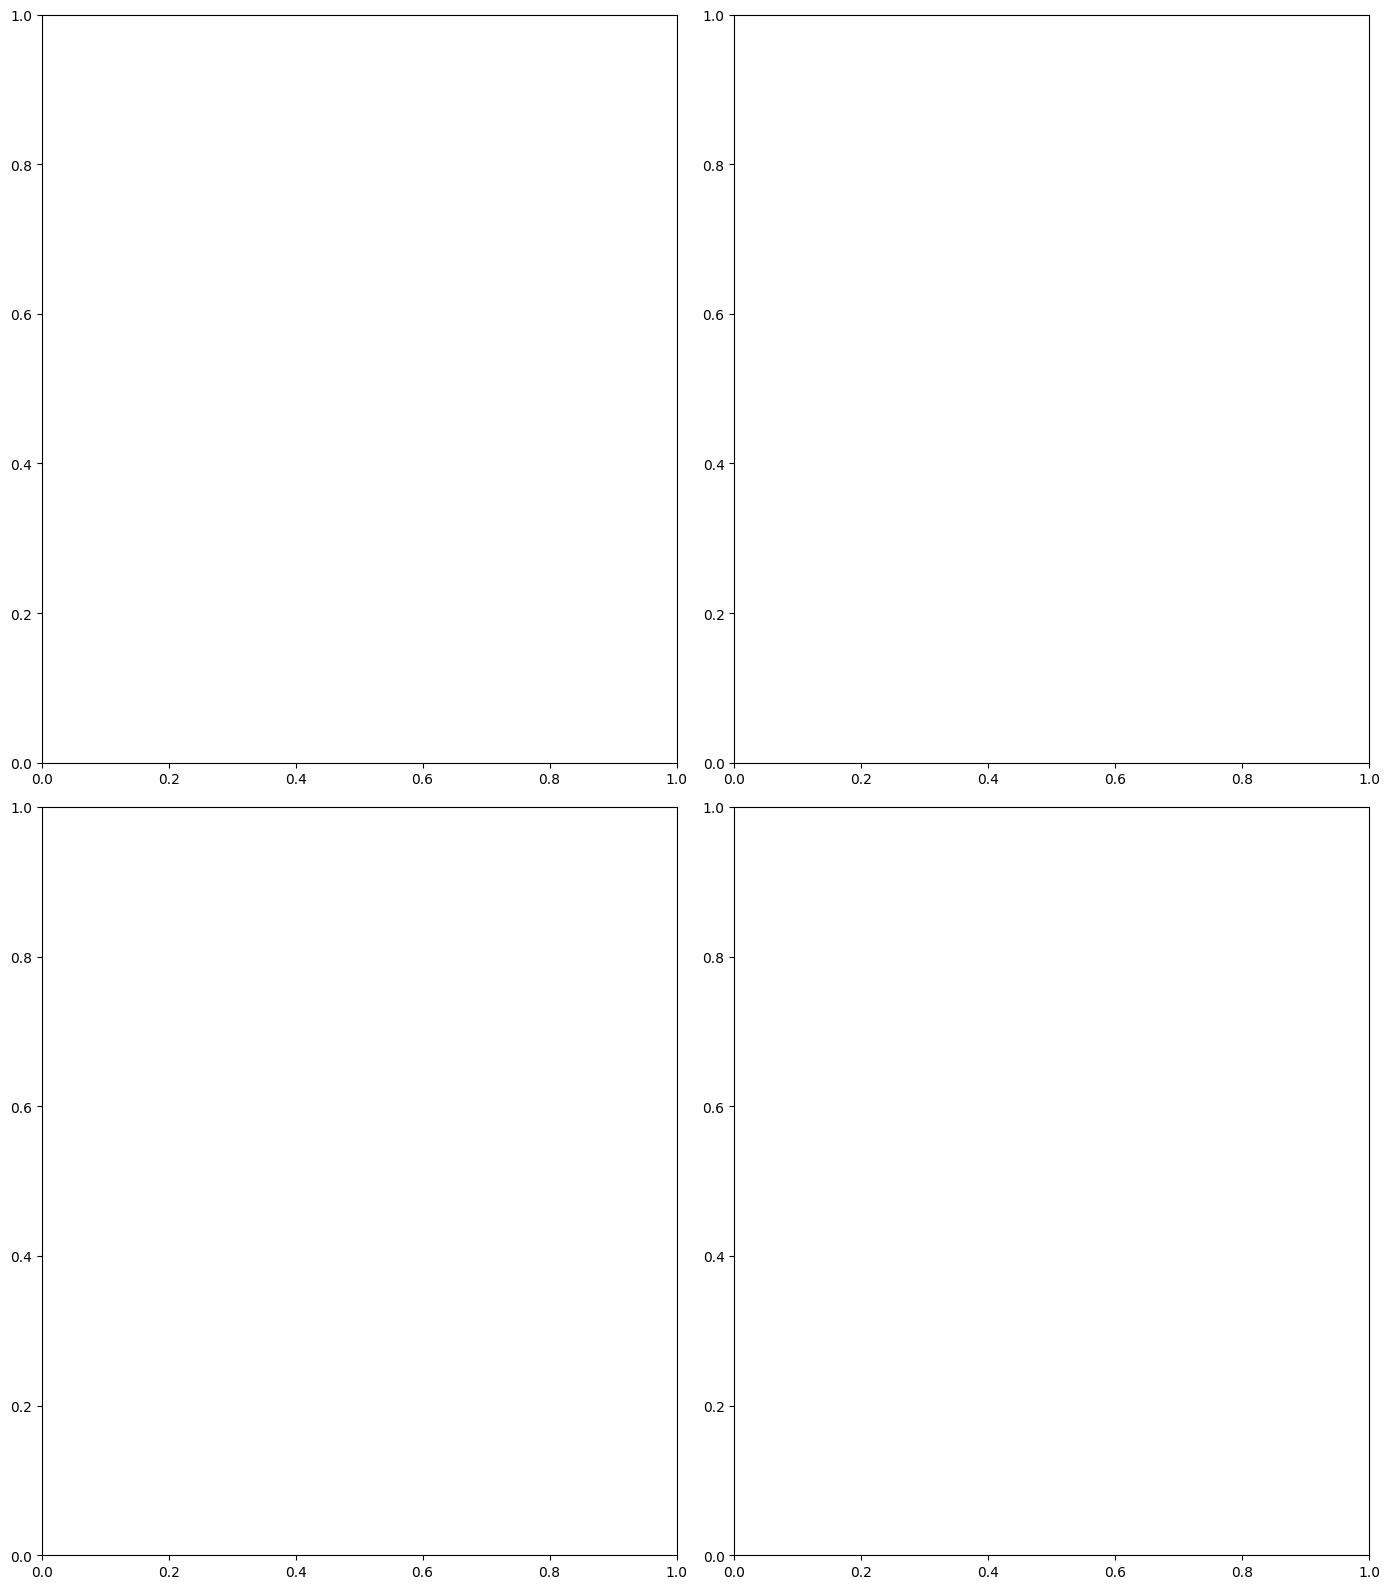

In [10]:
# restore data
trajectories = {}
geometries = {}
layout = 'Exit'

# 遍历不同宽度的文件
for width in np.arange(1.0, 1.8, 0.2):
    width = round(width, 1)
    
    # store all trajectories
    all_trajectories = []
    geometry = None
    
    # 读取5次重复实验
    for run in range(5):
        filename = f"./Big_Average/Exit/Width_{width}_{run}.sqlite"
        
        try:
            # 连接数据库
            conn = sqlite3.connect(filename)
            
            # 读取轨迹数据
            traj_df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)
            
            # 只读取一次几何数据（所有重复实验的几何应该相同）
            if geometry is None:
                geom_df = pd.read_sql_query("SELECT * FROM geometry", conn)
                if not geom_df.empty:
                    geometry = process_polygon(geom_df['wkt'].iloc[0])
            
            conn.close()
            
            # 添加运行编号标识
            traj_df['run'] = run
            all_trajectories.append(traj_df)
            
        except Exception as e:
            print(f"读取 {filename} 失败: {e}")
    
    # 合并所有重复实验的轨迹
    if all_trajectories and geometry is not None:
        combined_trajectories = pd.concat(all_trajectories, ignore_index=True)
        trajectories[width] = combined_trajectories
        geometries[width] = geometry
    else:
        print(f"宽度 {width} 的数据处理失败")

# 创建子图
fig, axes = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(14, 16)
)
axes = np.atleast_1d(axes)

# 设置轨迹样式
trajectory_color = 'red'
trajectory_alpha = 0.3
trajectory_linewidth = 0.8

for ax, (width, traj_df) in zip(axes.flatten(), trajectories.items()):
    
    # 计算坐标偏移量（用于标准化显示）
    x_min = min(traj_df['pos_x'].min(), geometries[width].bounds[0])  
    y_min = min(traj_df['pos_y'].min(), geometries[width].bounds[1])  
    
    geom = geometries[width]
    
    # 绘制几何边界
    if geom.geom_type == 'Polygon':  
        x, y = geom.exterior.xy
        x = np.array(x) - x_min
        y = np.array(y) - y_min
        ax.plot(x, y, 'k-', linewidth=2, label='Boundary') 
        
        # 绘制内部孔洞（如果有）
        for interior in geom.interiors:
            x_hole, y_hole = interior.xy
            x_hole = np.array(x_hole) - x_min
            y_hole = np.array(y_hole) - y_min
            ax.plot(x_hole, y_hole, 'k-', linewidth=2)
            
    elif geom.geom_type == 'MultiPolygon':  
        for poly in geom.geoms:  
            x, y = poly.exterior.xy  
            x = np.array(x) - x_min
            y = np.array(y) - y_min 
            ax.plot(x, y, 'k-', linewidth=2)
    
    # 绘制所有代理的轨迹（包括5次重复实验）
    for run in range(5):
        run_data = traj_df[traj_df['run'] == run]
        
        for agent_id in run_data['id'].unique():
            agent_traj = run_data[run_data['id'] == agent_id]
            
            # 按帧排序确保轨迹连续
            agent_traj = agent_traj.sort_values('frame')
            
            ax.plot(
                agent_traj['pos_x'] - x_min, 
                agent_traj['pos_y'] - y_min, 
                color=trajectory_color,
                alpha=trajectory_alpha,
                linewidth=trajectory_linewidth
            )
    
    # 设置图形属性
    ax.set_title(f"Layout {layout} - Corridor Width: {width}m (5 Runs Overlaid)", fontsize=12)
    ax.set_xlabel('Relative X (m)')
    ax.set_ylabel('Relative Y (m)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 添加图例（只在第一个子图）
    #if ax == axes.flatten()[0]:
        #ax.plot([], [], color=trajectory_color, alpha=trajectory_alpha, 
                #linewidth=trajectory_linewidth, label='Agent Trajectories')
        #ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'data/processed/trajectory_overlay_layout_{layout}.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计信息
print("轨迹叠加统计:")
for width, traj_df in trajectories.items():
    total_agents = len(traj_df.groupby(['run', 'id']))
    runs_count = len(traj_df['run'].unique())
    agents_per_run = len(traj_df[traj_df['run'] == 0]['id'].unique())
    
    print(f"宽度 {width}m: {runs_count} 次实验, 每次 {agents_per_run} 个代理, 总计 {total_agents} 条轨迹")